# XGB 05 — Evaluation

Load generated metrics and predictions and visualize performance without retraining.

In [3]:
# Import libraries
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "forecasting" / "xgboost"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "forecasting" / "xgboost"

REPORTS_DIR, OUTPUTS_DIR

(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/forecasting/xgboost'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/xgboost'))

In [4]:
# Get model metrics
global_metrics = pd.read_csv(REPORTS_DIR / "XGB_05_global_metrics.csv")
fold_metrics = pd.read_csv(REPORTS_DIR / "XGB_05_fold_metrics.csv")
fsa_metrics = pd.read_csv(REPORTS_DIR / "XGB_05_fsa_metrics.csv")
horizon_metrics = pd.read_csv(REPORTS_DIR / "XGB_05_horizon_metrics.csv")
predictions = pd.read_parquet(OUTPUTS_DIR / "xgboost_validation_predictions.parquet")
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["residual"] = predictions["actual"] - predictions["predicted"]


In [5]:
# Display Global metrics
display(global_metrics)

,model,mae,rmse,mape,wape,bias,n_observations
0,xgboost_regressor,606.265878,1106.771204,5.929867,6.662859,-251.046293,2519424


In [6]:
# Display Fold metrics
display(fold_metrics)

,fold,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,741.727772,1351.143366,6.864397,8.218963,-447.923609,1257984
1,fold_2024,471.175112,791.165093,4.997897,5.136220,-54.708367,1261440


In [7]:
# Display FSA metrics
display(fsa_metrics)

,fold,fsa,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,L4T,653.935387,1079.807492,5.412622,5.784239,-173.132353,209664
1,fold_2023,M5R,410.576047,593.211359,5.362848,5.511549,62.491105,209664
2,fold_2023,M5S,191.672888,268.516241,4.715872,4.807526,5.485751,209664
3,fold_2023,M6G,674.636083,1036.559377,5.438790,5.814093,-446.104085,209664
4,fold_2023,M9R,356.255620,603.399929,5.934880,6.427015,1.509767,209664
5,fold_2023,M9W,2163.290604,2815.137413,14.321371,15.171189,-2137.791838,209664
6,fold_2024,L4T,624.012390,1009.380511,4.967410,5.364765,-147.896886,210240
7,fold_2024,M5R,387.064071,552.239937,5.094822,5.156994,-1.243370,210240
8,fold_2024,M5S,194.688484,276.213041,4.865655,4.866624,36.692021,210240
9,fold_2024,M6G,561.079370,837.890522,4.674182,4.801137,-97.109812,210240


In [8]:
# Display Horizon metrics
display(horizon_metrics)

,fold,horizon,target,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,1,target_h01,516.563840,950.928646,4.831500,5.724698,-385.655362,52416
1,fold_2023,2,target_h02,547.552050,996.631963,5.082608,6.068067,-404.573147,52416
2,fold_2023,3,target_h03,576.657344,1039.975941,5.358133,6.390572,-418.178906,52416
3,fold_2023,4,target_h04,605.748911,1108.485578,5.566405,6.712923,-431.388658,52416
4,fold_2023,5,target_h05,634.746462,1141.448208,5.884838,7.034223,-450.349419,52416
5,fold_2023,6,target_h06,651.438019,1186.265668,5.991125,7.219137,-451.817907,52416
6,fold_2023,7,target_h07,686.190598,1246.447152,6.300874,7.604189,-465.653639,52416
7,fold_2023,8,target_h08,710.511125,1318.525350,6.477127,7.873624,-481.621043,52416
8,fold_2023,9,target_h09,734.853853,1345.068100,6.711091,8.143283,-494.807427,52416
9,fold_2023,10,target_h10,764.282253,1406.972588,6.948533,8.469268,-513.471869,52416


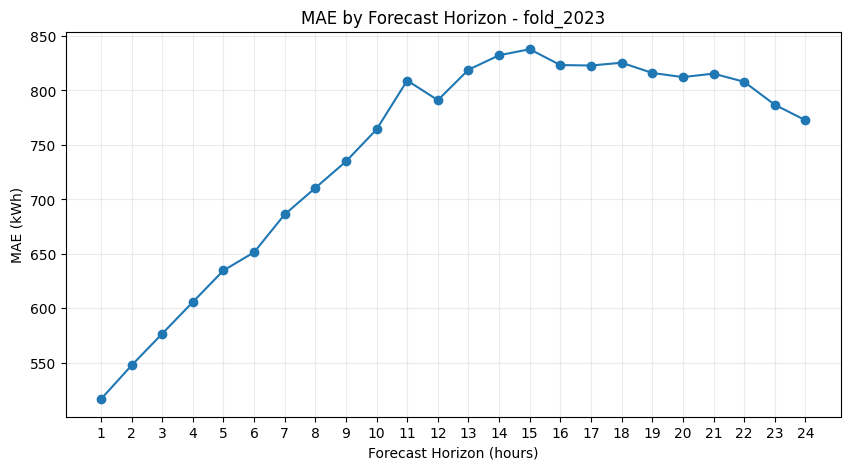

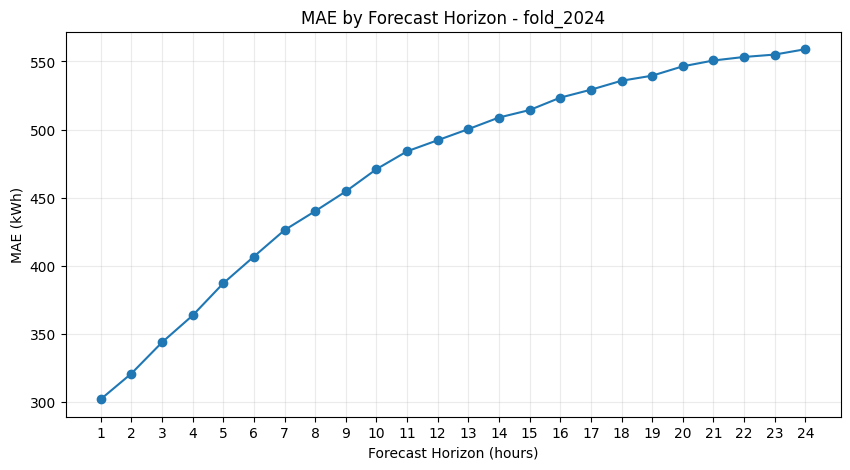

In [9]:
# MAE by Forecast Horizon 
for fold, group in horizon_metrics.groupby("fold"):
    plt.figure(figsize=(10, 5))
    plt.plot(group["horizon"], group["mae"], marker="o")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("MAE (kWh)")
    plt.title(f"MAE by Forecast Horizon - {fold}")
    plt.xticks(range(1, 25))
    plt.grid(alpha=0.25)
    plt.show()


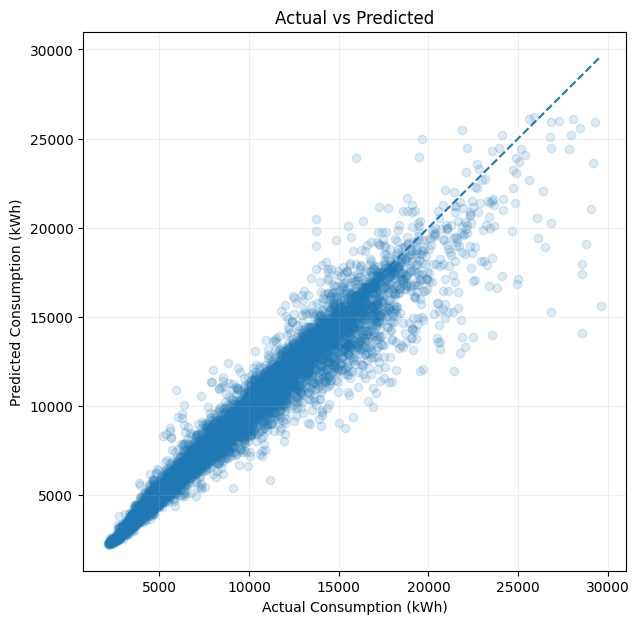

In [10]:
# Actual vs Predicted
sample = predictions.sample(n=min(10000, len(predictions)), random_state=42)
plt.figure(figsize=(7, 7))
plt.scatter(sample["actual"], sample["predicted"], alpha=0.15)
minimum = min(sample["actual"].min(), sample["predicted"].min())
maximum = max(sample["actual"].max(), sample["predicted"].max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.2)
plt.show()


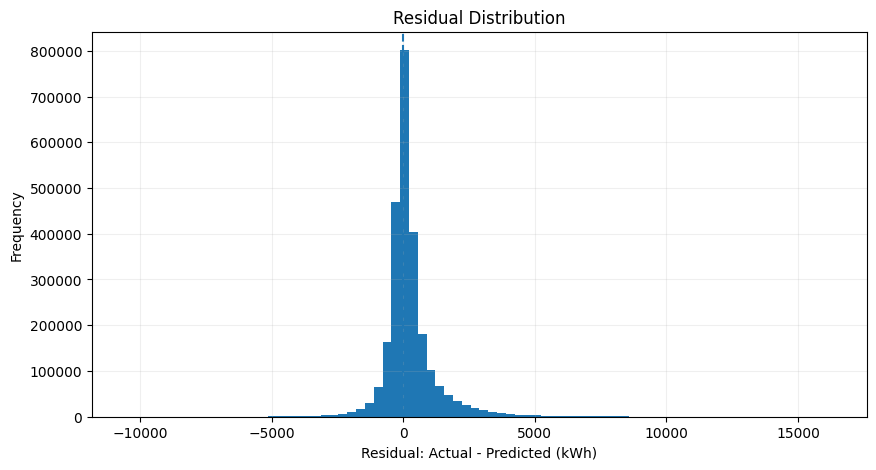

In [11]:
# Residual Distribution
plt.figure(figsize=(10, 5))
plt.hist(predictions["residual"].dropna(), bins=80)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual: Actual - Predicted (kWh)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(alpha=0.2)
plt.show()


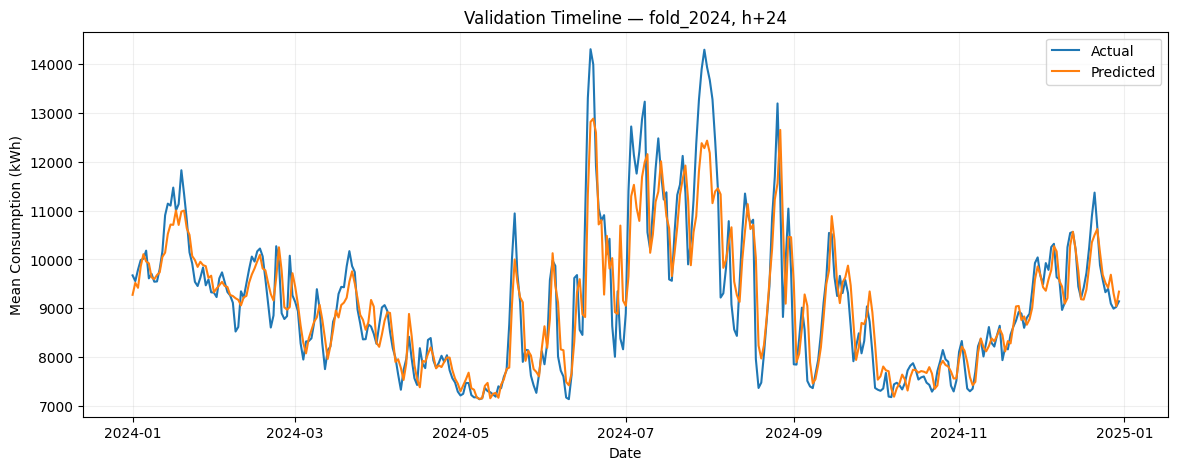

In [12]:
# Validation Timeline
timeline = predictions.query("fold == 'fold_2024' and horizon == 24").copy()
timeline["date"] = timeline["forecast_origin"].dt.floor("D")
daily = (
    timeline.groupby("date", observed=True)
    .agg(actual=("actual", "mean"), predicted=("predicted", "mean"))
    .reset_index()
)
plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["actual"], label="Actual")
plt.plot(daily["date"], daily["predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Mean Consumption (kWh)")
plt.title("Validation Timeline — fold_2024, h+24")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Additional Temporal and FSA Error Diagnostics

In [13]:
# Load previously generated XGBoost validation predictions.
# This section does not retrain the model.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# Define configuration path 
PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "modeling"
    / "forecasting"
    / "xgboost"
    / "xgboost_validation_predictions.parquet"
)
PREDICTIONS_PATH


WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/xgboost/xgboost_validation_predictions.parquet')

In [15]:
# Get predictions
predictions = pd.read_parquet(PREDICTIONS_PATH)

predictions["forecast_origin"] = pd.to_datetime(
    predictions["forecast_origin"]
)

# Error convention used for diagnostics:
# positive residual = underprediction
# negative residual = overprediction
predictions["residual"] = (
    predictions["actual"]
    - predictions["predicted"]
)

predictions["absolute_error"] = predictions["residual"].abs()

# Percentage error for diagnostic aggregation.
predictions["absolute_percentage_error"] = np.where(
    predictions["actual"] != 0,
    predictions["absolute_error"]
    / predictions["actual"].abs()
    * 100,
    np.nan,
)

predictions["year"] = predictions["forecast_origin"].dt.year
predictions["month_number"] = predictions["forecast_origin"].dt.month
predictions["month_name"] = predictions["forecast_origin"].dt.strftime("%b")

display(predictions.head())

print(f"Rows loaded: {len(predictions):,}")
print(f"FSAs: {sorted(predictions['fsa'].unique())}")
print(f"Folds: {sorted(predictions['fold'].unique())}")

,fold,fsa,forecast_origin,horizon,actual,predicted,residual,absolute_error,absolute_percentage_error,year,month_number,month_name
0,fold_2023,L4T,2023-01-01 00:00:00,1,8887.8,8540.450195,347.349805,347.349805,3.908164,2023,1,Ene.
1,fold_2023,L4T,2023-01-01 01:00:00,1,8343.7,7787.926270,555.773730,555.773730,6.660998,2023,1,Ene.
2,fold_2023,L4T,2023-01-01 02:00:00,1,8034.0,7455.713379,578.286621,578.286621,7.197991,2023,1,Ene.
3,fold_2023,L4T,2023-01-01 03:00:00,1,7736.1,7242.279785,493.820215,493.820215,6.383323,2023,1,Ene.
4,fold_2023,L4T,2023-01-01 04:00:00,1,7606.8,7172.475098,434.324902,434.324902,5.709693,2023,1,Ene.


Rows loaded: 2,519,424
FSAs: ['L4T', 'M5R', 'M5S', 'M6G', 'M9R', 'M9W']
Folds: ['fold_2023', 'fold_2024']


In [16]:
# Calculate monthly forecasting metrics by validation fold.
monthly_metrics = (
    predictions
    .groupby(
        [
            "fold",
            "year",
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "fold",
            "year",
            "month_number",
        ]
    )
)

display(monthly_metrics)

,fold,year,month_number,month_name,observations,mae,mape,mean_residual,actual_mean,predicted_mean
0,fold_2023,2023,1,Ene.,107136,484.856933,4.521145,303.534273,9689.395584,9385.861328
1,fold_2023,2023,2,Feb.,96768,659.139032,6.148016,354.518237,9756.330448,9401.812500
2,fold_2023,2023,3,Mar.,107136,599.409608,5.844747,328.494231,9208.743095,8880.249023
3,fold_2023,2023,4,Abr.,103680,529.587214,5.745163,324.312783,8088.189191,7763.876465
4,fold_2023,2023,5,May.,107136,577.689450,5.945432,410.269066,7730.152050,7319.882812
5,fold_2023,2023,6,Jun.,103680,947.675810,8.567974,552.682511,9050.545692,8497.863281
6,fold_2023,2023,7,Jul.,107136,1427.426729,11.126871,791.563638,10847.802063,10056.239258
7,fold_2023,2023,8,Ago.,107136,1066.388054,9.794901,481.363714,9338.000313,8856.636719
8,fold_2023,2023,9,Set.,103680,1043.509080,8.994134,800.783958,8715.273743,7914.489746
9,fold_2023,2023,10,Oct.,107136,552.607306,5.855009,341.229800,7912.513776,7571.283691


### Monthly MAE

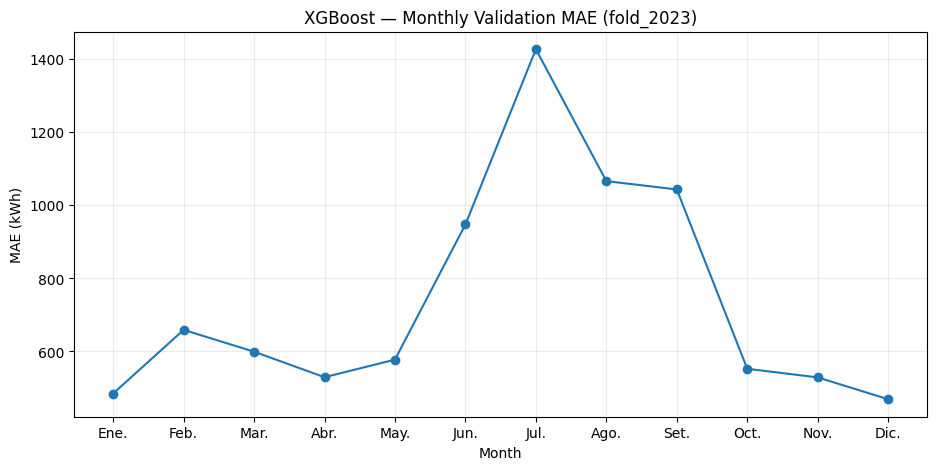

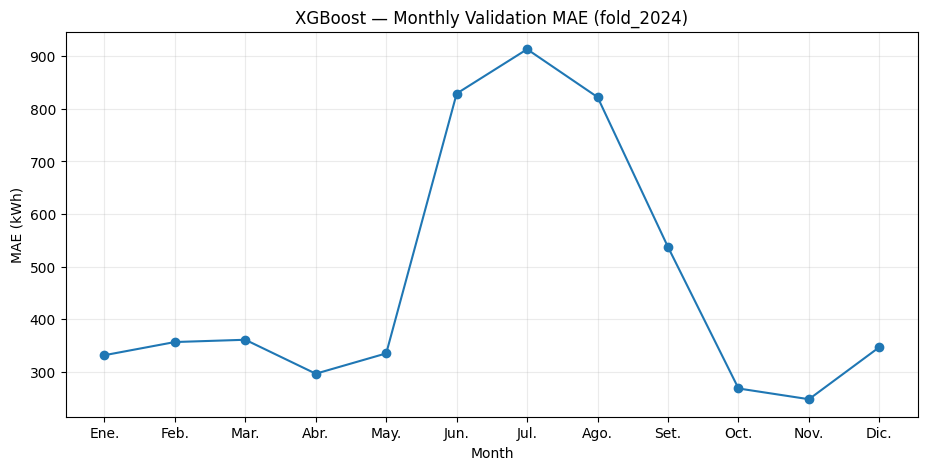

In [17]:
# Plot monthly MAE for each validation fold.
for fold, group in monthly_metrics.groupby("fold"):

    plt.figure(figsize=(11, 5))

    plt.plot(
        group["month_name"],
        group["mae"],
        marker="o",
    )

    plt.xlabel("Month")
    plt.ylabel("MAE (kWh)")
    plt.title(
        f"XGBoost — Monthly Validation MAE ({fold})"
    )

    plt.grid(alpha=0.25)
    plt.show()

### Monthly Bias / Residual

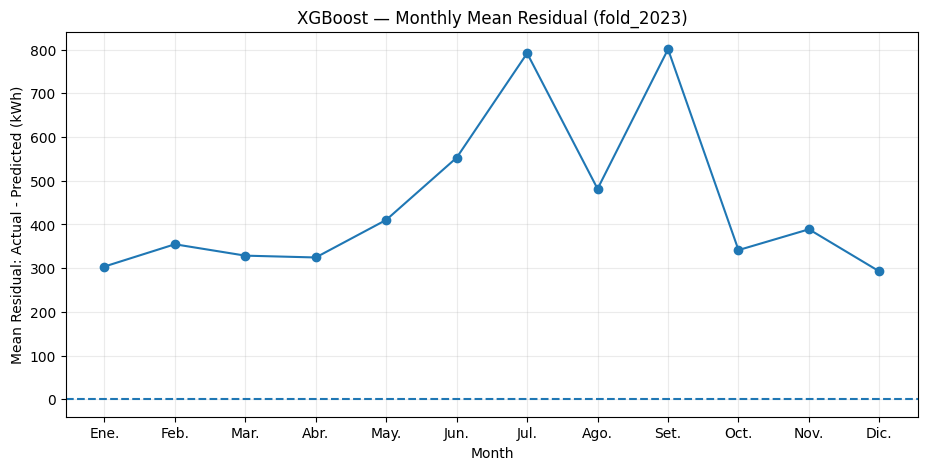

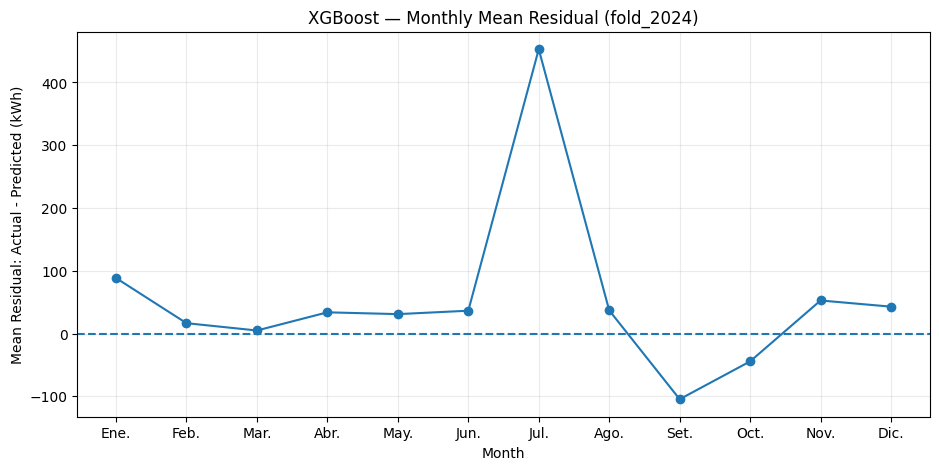

In [18]:
# Plot monthly mean residual by validation fold.
for fold, group in monthly_metrics.groupby("fold"):

    plt.figure(figsize=(11, 5))

    plt.plot(
        group["month_name"],
        group["mean_residual"],
        marker="o",
    )

    plt.axhline(
        0,
        linestyle="--",
    )

    plt.xlabel("Month")
    plt.ylabel("Mean Residual: Actual - Predicted (kWh)")
    plt.title(
        f"XGBoost — Monthly Mean Residual ({fold})"
    )

    plt.grid(alpha=0.25)
    plt.show()

### Error by month by FSA

In [19]:
# Calculate monthly forecasting metrics by FSA.
monthly_fsa_metrics = (
    predictions
    .groupby(
        [
            "fold",
            "year",
            "month_number",
            "month_name",
            "fsa",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "fold",
            "fsa",
            "year",
            "month_number",
        ]
    )
)

display(monthly_fsa_metrics.head(30))

,fold,year,month_number,month_name,fsa,observations,mae,mape,mean_residual,actual_mean,predicted_mean
0,fold_2023,2023,1,Ene.,L4T,17856,315.643259,2.841020,68.563632,11266.489830,11197.926758
6,fold_2023,2023,2,Feb.,L4T,16128,402.219589,3.508376,43.290674,11317.397371,11274.107422
12,fold_2023,2023,3,Mar.,L4T,17856,384.964011,3.556685,70.468007,10798.958205,10728.490234
18,fold_2023,2023,4,Abr.,L4T,17280,406.336858,4.111837,212.832892,9954.833657,9742.000977
24,fold_2023,2023,5,May.,L4T,17856,509.723590,4.899375,317.984654,9962.615541,9644.630859
30,fold_2023,2023,6,Jun.,L4T,17280,975.767660,7.910779,176.087332,12019.116024,11843.028320
36,fold_2023,2023,7,Jul.,L4T,17856,1464.882187,10.196561,-27.293181,14512.347278,14539.640625
42,fold_2023,2023,8,Ago.,L4T,17856,1168.441201,9.211666,40.387073,12565.724222,12525.336914
48,fold_2023,2023,9,Set.,L4T,17280,1070.071380,7.883413,661.229688,11511.567205,10850.337891
54,fold_2023,2023,10,Oct.,L4T,17856,439.484337,4.275596,175.800800,10010.141969,9834.341797


In [20]:
# Optional: save monthly FSA diagnostics.
OUTPUT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "forecasting"
    / "xgboost"
    / "XGB_05_monthly_fsa_metrics.csv"
)

monthly_fsa_metrics.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved: {OUTPUT_PATH}")

Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\modeling\forecasting\xgboost\XGB_05_monthly_fsa_metrics.csv


### Heatmap FSA × Month — MAE

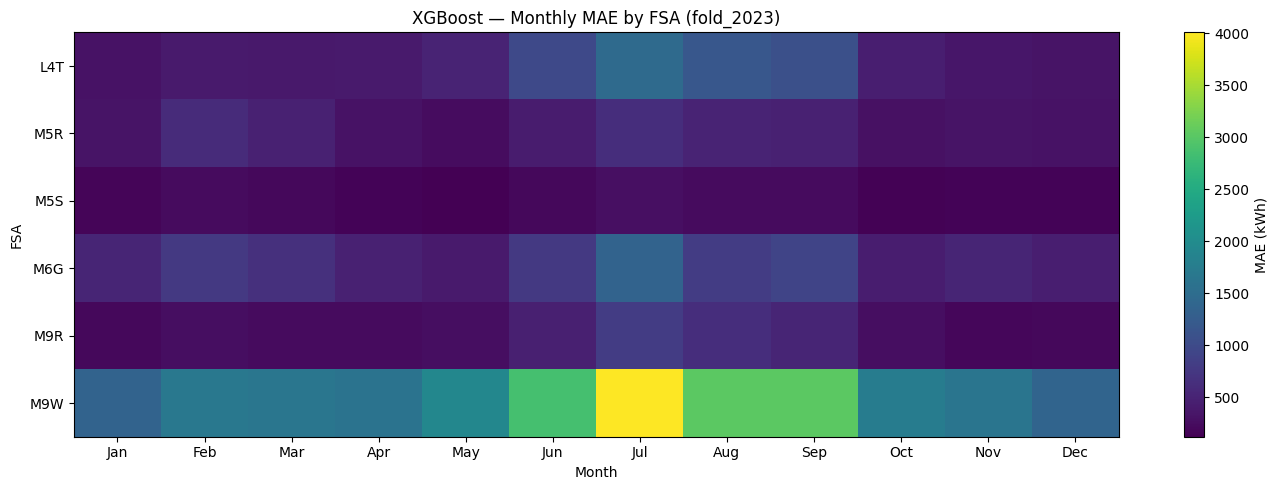

In [21]:
# Create MAE heatmap for fold_2023.
heatmap_2023 = (
    monthly_fsa_metrics[
        monthly_fsa_metrics["fold"] == "fold_2023"
    ]
    .pivot(
        index="fsa",
        columns="month_number",
        values="mae",
    )
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec",
]

plt.figure(figsize=(14, 5))

image = plt.imshow(
    heatmap_2023.values,
    aspect="auto",
)

plt.yticks(
    range(len(heatmap_2023.index)),
    heatmap_2023.index,
)

plt.xticks(
    range(12),
    month_labels,
)

plt.xlabel("Month")
plt.ylabel("FSA")

plt.title(
    "XGBoost — Monthly MAE by FSA (fold_2023)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

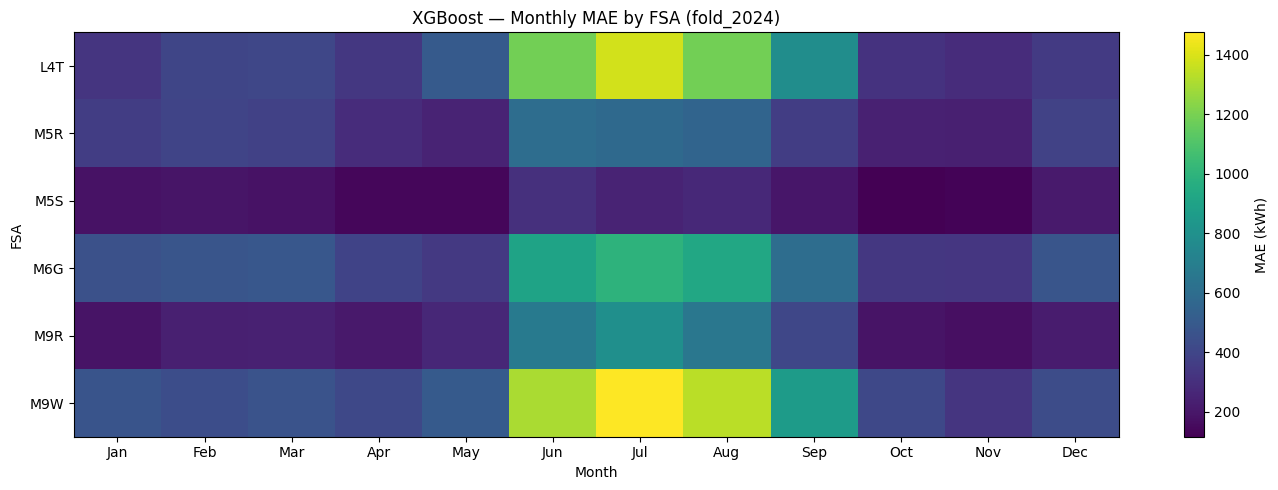

In [22]:
# Create MAE heatmap for fold_2024.
heatmap_2024 = (
    monthly_fsa_metrics[
        monthly_fsa_metrics["fold"] == "fold_2024"
    ]
    .pivot(
        index="fsa",
        columns="month_number",
        values="mae",
    )
)

plt.figure(figsize=(14, 5))

image = plt.imshow(
    heatmap_2024.values,
    aspect="auto",
)

plt.yticks(
    range(len(heatmap_2024.index)),
    heatmap_2024.index,
)

plt.xticks(
    range(12),
    month_labels,
)

plt.xlabel("Month")
plt.ylabel("FSA")

plt.title(
    "XGBoost — Monthly MAE by FSA (fold_2024)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### Heatmap FSA × Fold

In [23]:
# Aggregate MAE by FSA and validation fold.
fsa_fold_mae = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

display(fsa_fold_mae)

,fold,fsa,mae
0,fold_2023,L4T,653.935387
1,fold_2023,M5R,410.576047
2,fold_2023,M5S,191.672888
3,fold_2023,M6G,674.636083
4,fold_2023,M9R,356.255620
5,fold_2023,M9W,2163.290604
6,fold_2024,L4T,624.012390
7,fold_2024,M5R,387.064071
8,fold_2024,M5S,194.688484
9,fold_2024,M6G,561.079370


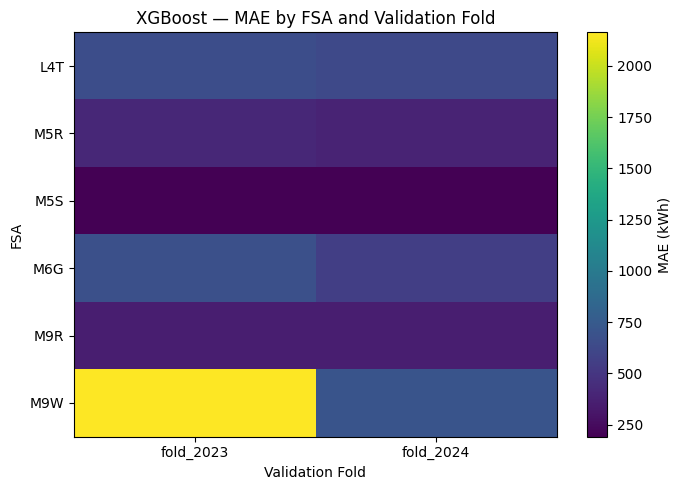

In [24]:
# Heatmap of MAE by FSA and fold.
fsa_fold_pivot = (
    fsa_fold_mae
    .pivot(
        index="fsa",
        columns="fold",
        values="mae",
    )
)

plt.figure(figsize=(7, 5))

image = plt.imshow(
    fsa_fold_pivot.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_fold_pivot.index)),
    fsa_fold_pivot.index,
)

plt.xticks(
    range(len(fsa_fold_pivot.columns)),
    fsa_fold_pivot.columns,
)

plt.xlabel("Validation Fold")
plt.ylabel("FSA")

plt.title(
    "XGBoost — MAE by FSA and Validation Fold"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### FSA × Horizon

In [26]:
# Calculate MAE by FSA, fold, and forecast horizon.
fsa_horizon_mae = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
            "horizon",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

display(fsa_horizon_mae.head())

,fold,fsa,horizon,mae
0,fold_2023,L4T,1,415.688447
1,fold_2023,L4T,2,420.305732
2,fold_2023,L4T,3,474.070904
3,fold_2023,L4T,4,479.488846
4,fold_2023,L4T,5,556.253190


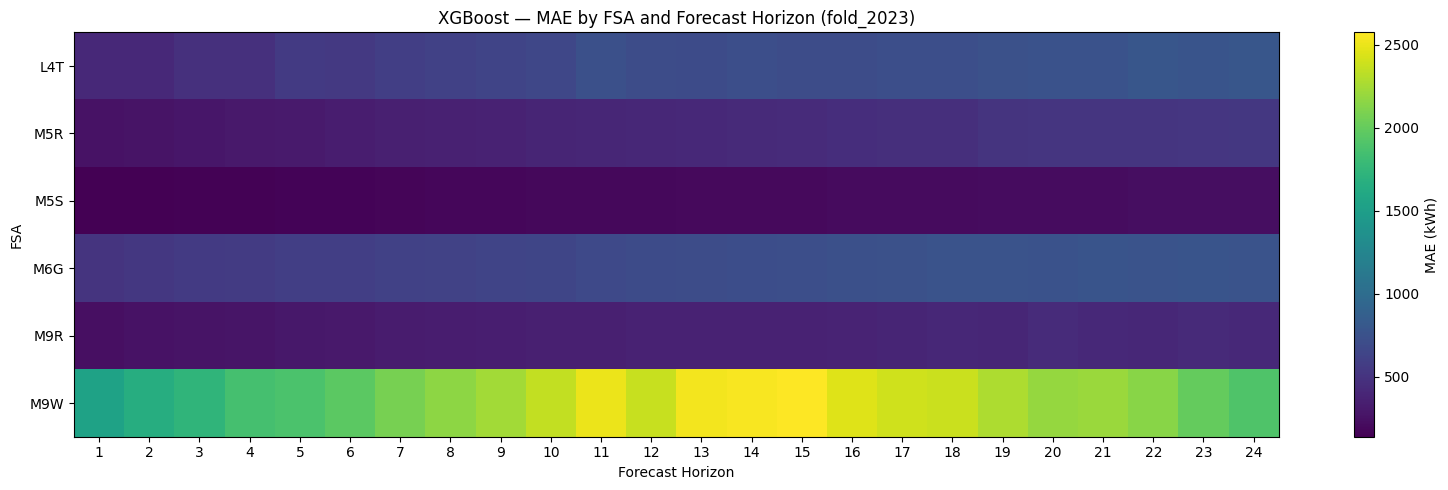

In [27]:
# Heatmap of MAE by FSA and forecast horizon for fold_2023.
fsa_horizon_2023 = (
    fsa_horizon_mae[
        fsa_horizon_mae["fold"] == "fold_2023"
    ]
    .pivot(
        index="fsa",
        columns="horizon",
        values="mae",
    )
)

plt.figure(figsize=(16, 5))

image = plt.imshow(
    fsa_horizon_2023.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_horizon_2023.index)),
    fsa_horizon_2023.index,
)

plt.xticks(
    range(24),
    range(1, 25),
)

plt.xlabel("Forecast Horizon")
plt.ylabel("FSA")

plt.title(
    "XGBoost — MAE by FSA and Forecast Horizon (fold_2023)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

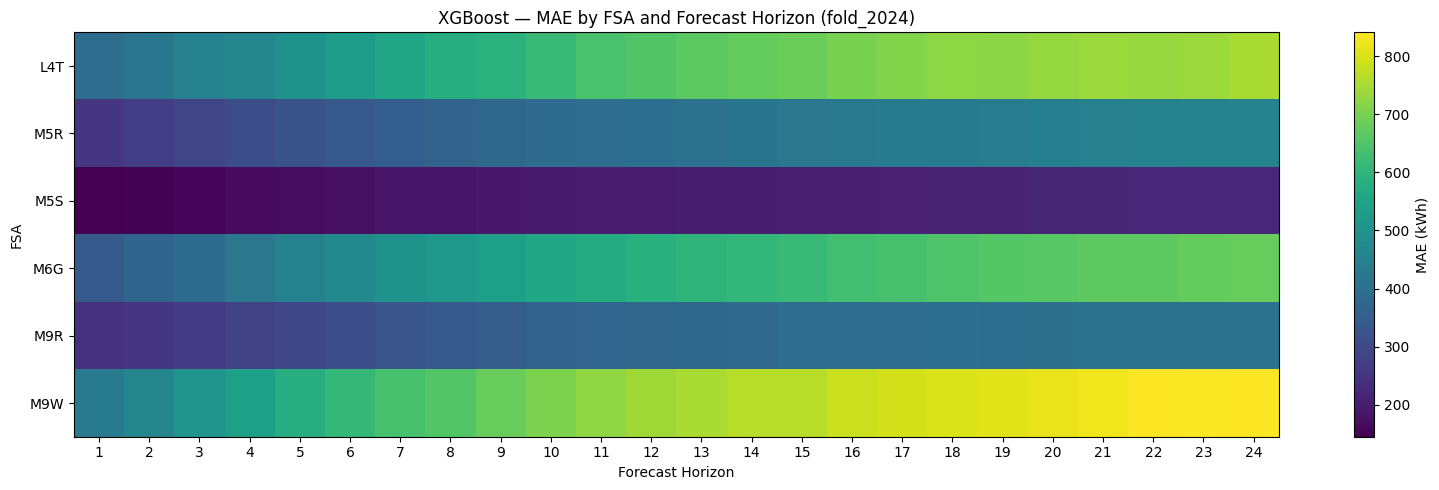

In [28]:
# Heatmap of MAE by FSA and forecast horizon for fold_2024.
fsa_horizon_2024 = (
    fsa_horizon_mae[
        fsa_horizon_mae["fold"] == "fold_2024"
    ]
    .pivot(
        index="fsa",
        columns="horizon",
        values="mae",
    )
)

plt.figure(figsize=(16, 5))

image = plt.imshow(
    fsa_horizon_2024.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_horizon_2024.index)),
    fsa_horizon_2024.index,
)

plt.xticks(
    range(24),
    range(1, 25),
)

plt.xlabel("Forecast Horizon")
plt.ylabel("FSA")

plt.title(
    "XGBoost — MAE by FSA and Forecast Horizon (fold_2024)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()

### Análisis específico de M9W-2023

In [29]:
# Isolate M9W during the 2023 validation fold.
m9w_2023 = (
    predictions[
        (predictions["fold"] == "fold_2023")
        & (predictions["fsa"] == "M9W")
    ]
    .copy()
)

print(
    f"M9W-2023 observations: {len(m9w_2023):,}"
)

display(
    m9w_2023.head()
)

M9W-2023 observations: 209,664


,fold,fsa,forecast_origin,horizon,actual,predicted,residual,absolute_error,absolute_percentage_error,year,month_number,month_name
43680,fold_2023,M9W,2023-01-01 00:00:00,1,10386.7,10344.082031,42.617969,42.617969,0.410313,2023,1,Ene.
43681,fold_2023,M9W,2023-01-01 01:00:00,1,9824.2,9515.027344,309.172656,309.172656,3.147052,2023,1,Ene.
43682,fold_2023,M9W,2023-01-01 02:00:00,1,9433.5,9300.436523,133.063477,133.063477,1.410542,2023,1,Ene.
43683,fold_2023,M9W,2023-01-01 03:00:00,1,9162.5,9172.879883,-10.379883,10.379883,0.113287,2023,1,Ene.
43684,fold_2023,M9W,2023-01-01 04:00:00,1,9096.0,9164.790039,-68.790039,68.790039,0.756267,2023,1,Ene.


In [30]:
# Summarize M9W-2023 error behavior.
m9w_2023_summary = pd.DataFrame(
    [
        {
            "observations": len(m9w_2023),
            "actual_mean": m9w_2023["actual"].mean(),
            "predicted_mean": m9w_2023["predicted"].mean(),
            "mae": m9w_2023["absolute_error"].mean(),
            "mape": m9w_2023["absolute_percentage_error"].mean(),
            "mean_residual": m9w_2023["residual"].mean(),
            "median_residual": m9w_2023["residual"].median(),
            "p95_absolute_error": (
                m9w_2023["absolute_error"]
                .quantile(0.95)
            ),
            "maximum_absolute_error": (
                m9w_2023["absolute_error"]
                .max()
            ),
        }
    ]
)

display(m9w_2023_summary)

,observations,actual_mean,predicted_mean,mae,mape,mean_residual,median_residual,p95_absolute_error,maximum_absolute_error
0,209664,14259.203217,12121.411133,2163.290604,14.321371,2137.791838,1705.188184,5750.849873,16277.425586


### M9W-2023 by month

In [31]:
# Calculate monthly diagnostics for M9W during 2023.
m9w_2023_monthly = (
    m9w_2023
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
    .sort_values(
        "month_number"
    )
)

display(m9w_2023_monthly)

,month_number,month_name,observations,actual_mean,predicted_mean,mae,mape,mean_residual
0,1,Ene.,17856,14738.861598,13430.470703,1356.109438,9.015035,1308.391364
1,2,Feb.,16128,14916.540960,13241.453125,1682.052899,11.125968,1675.087802
2,3,Mar.,17856,14345.509050,12719.005859,1644.077319,11.314664,1626.503505
3,4,Abr.,17280,13025.586580,11435.041016,1596.629831,12.034094,1590.546117
4,5,May.,17856,12669.597665,10754.320312,1922.239544,14.297636,1915.276700
5,6,Jun.,17280,14427.741134,11593.090820,2860.089841,18.803124,2834.649956
6,7,Jul.,17856,16919.120934,13010.553711,4007.854667,22.100544,3908.566725
7,8,Ago.,17856,14915.903584,11923.278320,3034.715479,19.379794,2992.624912
8,9,Set.,17280,13939.556667,10909.348633,3032.566766,19.703613,3030.207771
9,10,Oct.,17856,12769.972961,11023.890625,1754.587475,13.040052,1746.082449


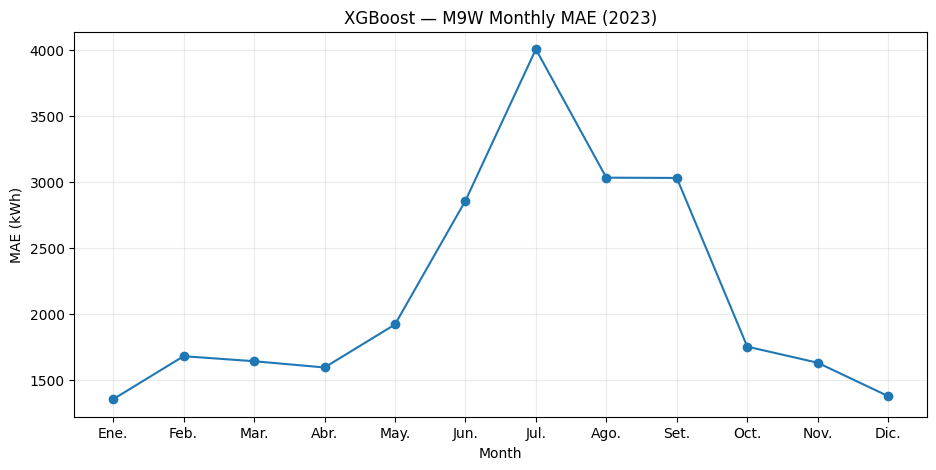

In [32]:
# Plot M9W-2023 monthly MAE.
plt.figure(figsize=(11, 5))

plt.plot(
    m9w_2023_monthly["month_name"],
    m9w_2023_monthly["mae"],
    marker="o",
)

plt.xlabel("Month")
plt.ylabel("MAE (kWh)")

plt.title(
    "XGBoost — M9W Monthly MAE (2023)"
)

plt.grid(alpha=0.25)
plt.show()

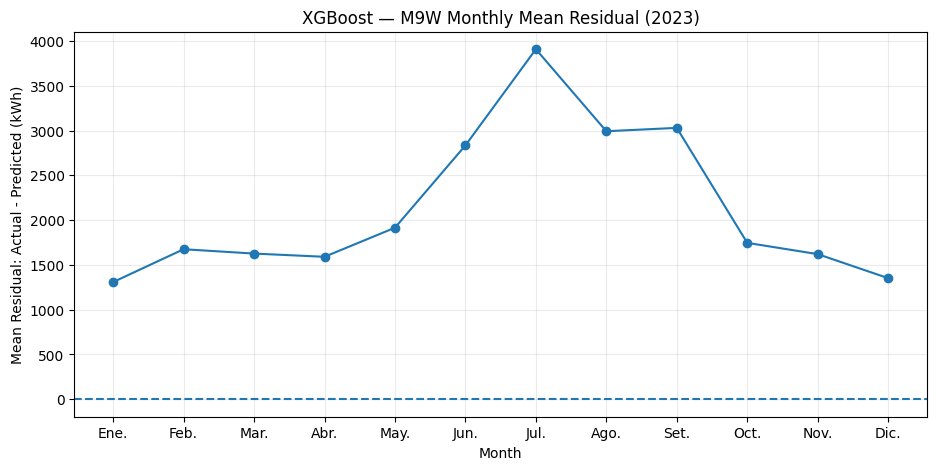

In [33]:
# Plot M9W-2023 monthly mean residual.
plt.figure(figsize=(11, 5))

plt.plot(
    m9w_2023_monthly["month_name"],
    m9w_2023_monthly["mean_residual"],
    marker="o",
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Month")
plt.ylabel(
    "Mean Residual: Actual - Predicted (kWh)"
)

plt.title(
    "XGBoost — M9W Monthly Mean Residual (2023)"
)

plt.grid(alpha=0.25)
plt.show()

### M9W-2023 Actual vs Predicted — timeline anual

In [34]:
# Select one horizon to visualize M9W-2023 over time.
m9w_h24 = (
    m9w_2023[
        m9w_2023["horizon"] == 24
    ]
    .sort_values(
        "forecast_origin"
    )
    .copy()
)

m9w_h24["date"] = (
    m9w_h24[
        "forecast_origin"
    ]
    .dt.floor("D")
)

m9w_h24_daily = (
    m9w_h24
    .groupby(
        "date",
        observed=True,
    )
    .agg(
        actual=("actual", "mean"),
        predicted=("predicted", "mean"),
    )
    .reset_index()
)

display(
    m9w_h24_daily.head()
)

,date,actual,predicted
0,2023-01-01,12148.604167,12381.863281
1,2023-01-02,12896.716667,12500.110352
2,2023-01-03,14120.195833,12978.015625
3,2023-01-04,14381.362500,13731.280273
4,2023-01-05,14339.466667,14061.416992


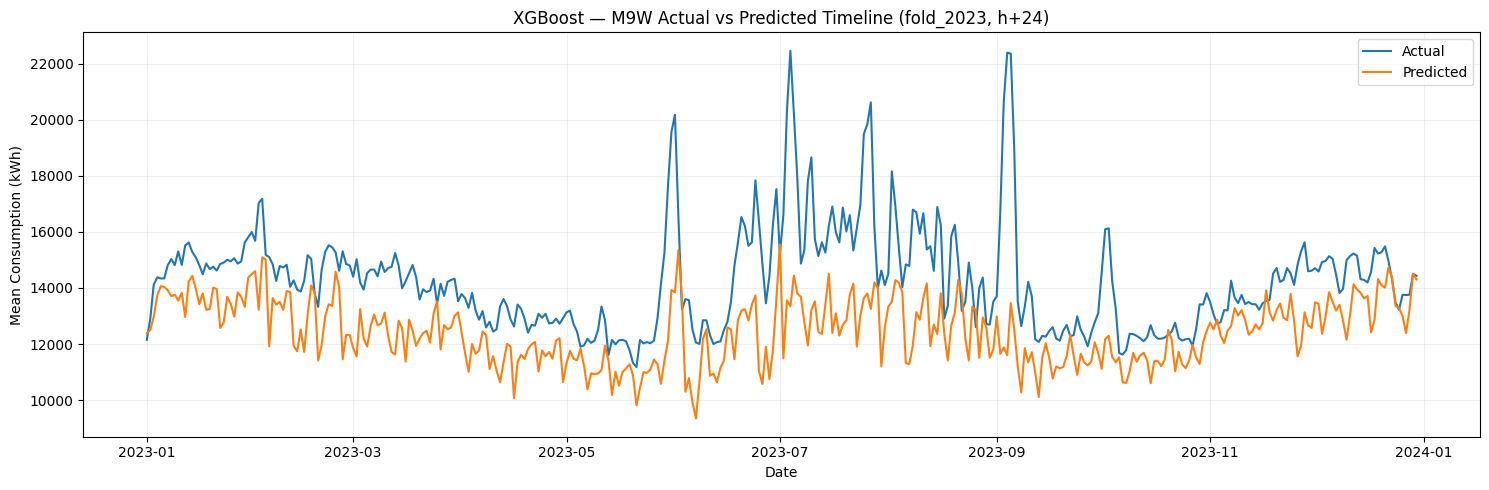

In [35]:
# Plot M9W-2023 Actual vs Predicted timeline.
plt.figure(figsize=(15, 5))

plt.plot(
    m9w_h24_daily["date"],
    m9w_h24_daily["actual"],
    label="Actual",
)

plt.plot(
    m9w_h24_daily["date"],
    m9w_h24_daily["predicted"],
    label="Predicted",
)

plt.xlabel("Date")
plt.ylabel("Mean Consumption (kWh)")

plt.title(
    "XGBoost — M9W Actual vs Predicted Timeline "
    "(fold_2023, h+24)"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### M9W-2023 residual timeline

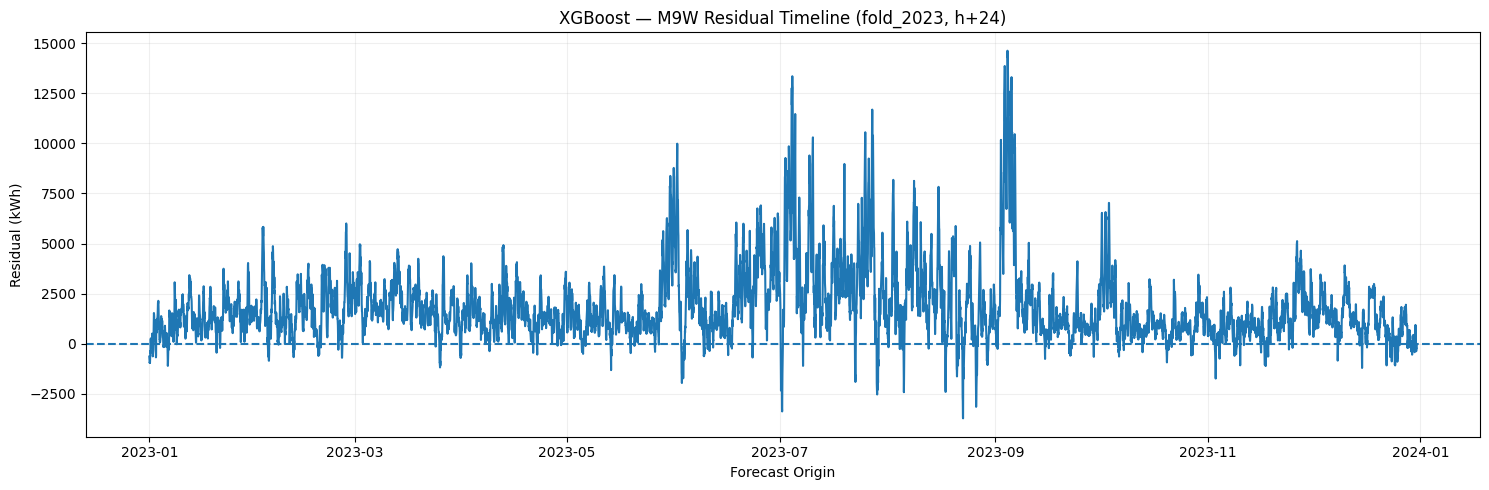

In [36]:
# Plot M9W-2023 residual timeline for h+24.
m9w_h24["residual"] = (
    m9w_h24["actual"]
    - m9w_h24["predicted"]
)

plt.figure(figsize=(15, 5))

plt.plot(
    m9w_h24["forecast_origin"],
    m9w_h24["residual"],
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Forecast Origin")
plt.ylabel("Residual (kWh)")

plt.title(
    "XGBoost — M9W Residual Timeline "
    "(fold_2023, h+24)"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

In [37]:
# Compare actual and predicted monthly mean demand for M9W-2023.
m9w_level_comparison = (
    m9w_2023
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        "month_number"
    )
)

m9w_level_comparison[
    "difference_kwh"
] = (
    m9w_level_comparison["actual_mean"]
    - m9w_level_comparison["predicted_mean"]
)

m9w_level_comparison[
    "difference_pct"
] = (
    m9w_level_comparison["difference_kwh"]
    / m9w_level_comparison["actual_mean"]
    * 100
)

display(
    m9w_level_comparison
)

,month_number,month_name,actual_mean,predicted_mean,difference_kwh,difference_pct
0,1,Ene.,14738.861598,13430.470703,1308.390895,8.877150
1,2,Feb.,14916.540960,13241.453125,1675.087835,11.229734
2,3,Mar.,14345.509050,12719.005859,1626.503191,11.338065
3,4,Abr.,13025.586580,11435.041016,1590.545564,12.210932
4,5,May.,12669.597665,10754.320312,1915.277352,15.117113
5,6,Jun.,14427.741134,11593.090820,2834.650314,19.647222
6,7,Jul.,16919.120934,13010.553711,3908.567223,23.101479
7,8,Ago.,14915.903584,11923.278320,2992.625264,20.063319
8,9,Set.,13939.556667,10909.348633,3030.208034,21.738195
9,10,Oct.,12769.972961,11023.890625,1746.082336,13.673344


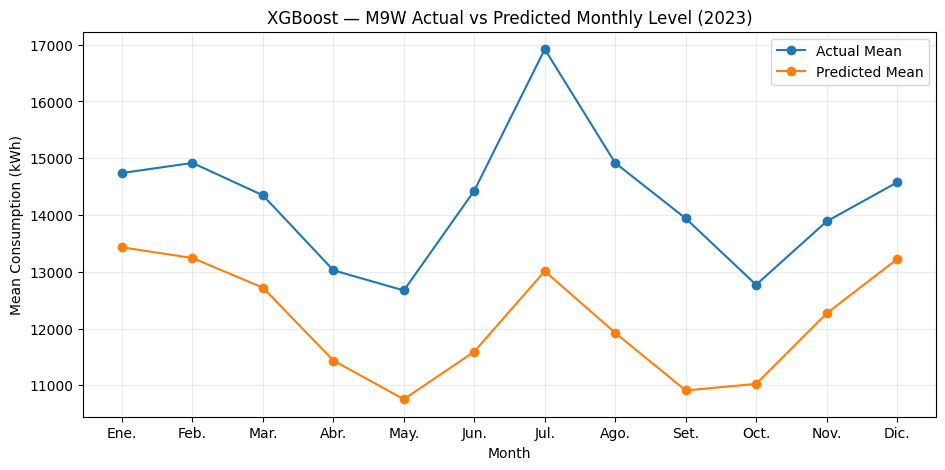

In [38]:
# Compare monthly actual and predicted demand levels.
plt.figure(figsize=(11, 5))

plt.plot(
    m9w_level_comparison["month_name"],
    m9w_level_comparison["actual_mean"],
    marker="o",
    label="Actual Mean",
)

plt.plot(
    m9w_level_comparison["month_name"],
    m9w_level_comparison["predicted_mean"],
    marker="o",
    label="Predicted Mean",
)

plt.xlabel("Month")
plt.ylabel("Mean Consumption (kWh)")

plt.title(
    "XGBoost — M9W Actual vs Predicted Monthly Level (2023)"
)

plt.legend()
plt.grid(alpha=0.25)

plt.show()

In [39]:
# Compare M9W with the remaining FSAs during fold_2023.
comparison_2023 = predictions[
    predictions["fold"] == "fold_2023"
].copy()

comparison_2023["group"] = np.where(
    comparison_2023["fsa"] == "M9W",
    "M9W",
    "Other FSAs",
)

m9w_vs_others = (
    comparison_2023
    .groupby(
        "group",
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(
    m9w_vs_others
)

,group,observations,actual_mean,predicted_mean,mae,mape,mean_residual
0,M9W,209664,14259.203217,12121.411133,2163.290604,14.321371,2137.791838
1,Other FSAs,1048320,7977.667853,7867.717773,457.415205,5.373002,109.949963
